Task 3: Heart Disease Prediction

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [21]:
df = pd.read_csv(r"C:\Users\DG\Downloads\heart_disease_uci.csv")

In [22]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


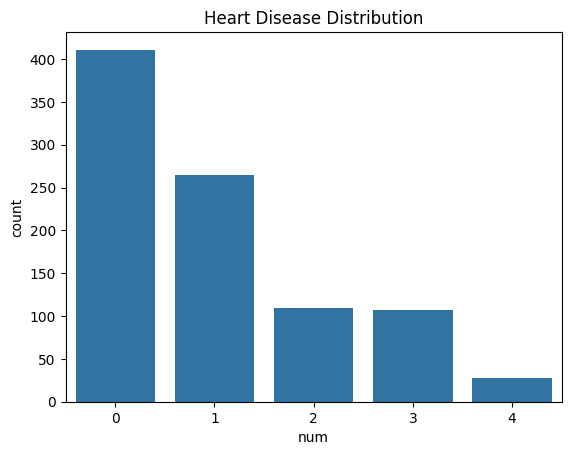

In [23]:
sns.countplot(x="num", data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [24]:
# Clean column names
df.columns = df.columns.str.strip()

df = df.drop(["id", "dataset"], axis=1)

# Convert target to binary (0 = No disease, 1 = Disease)
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)
df = df.fillna(df.median(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)

X = df.drop("num", axis=1)
y = df["num"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [28]:
y_pred = model.predict(X_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8043478260869565
